# Lab 7: Building a Transformer from Scratch

In this notebook we build a **decoder-only Transformer** (GPT-style) from scratch using PyTorch and train it as a **character-level language model**. By the end, the model will generate text in the style of Shakespeare.

This lab implements all the components described in the course notes:

1. **Positional Encoding** — injecting position into a permutation-invariant architecture.
2. **Scaled Dot-Product Attention** — the core operation of the Transformer.
3. **Multi-Head Attention** — running several attention computations in parallel.
4. **Feed-Forward Sub-Layer** — position-wise non-linear transformation.
5. **Layer Normalization** vs. Batch Normalization — why Transformers use LayerNorm.
6. **RMSNorm** — a lighter, bias-free alternative to LayerNorm used in LLaMA, Mistral, and Gemma.
7. **Residual Connections** — the gradient highway that makes deep Transformers trainable.
8. **Training loop** with causal masking and gradient clipping.
9. **Text generation** and **attention weight visualisation**.

**Dataset:** The complete works of Shakespeare (~1 MB, ~1 million characters) downloaded directly from GitHub (`karpathy/char-rnn`), split 90/10 into train and validation sets.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


PyTorch version: 2.10.0
Device: mps


---
## Part 1: Data Preparation

We load the full Shakespeare corpus (~1 MB, ~1 million characters) by downloading Karpathy's `tiny-shakespeare` text file directly from GitHub using Python's standard `urllib` library — no extra dependencies needed. We then split it 90 / 10 into **train** and **validation** sets so we can monitor generalisation during training.

**Character-level tokenisation:** the vocabulary consists of all unique characters in the training text (65 characters for the complete Shakespeare). Each character is mapped to an integer index.


In [31]:
# ── Download the full Shakespeare corpus (Karpathy's tiny-shakespeare, ~1 MB) ─
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
with urllib.request.urlopen(URL) as response:
    full_text = response.read().decode("utf-8")

# 90 / 10 train / validation split
split      = int(0.9 * len(full_text))
text_train = full_text[:split]
text_val   = full_text[split:]

# ── Character-level vocabulary (built from training text) ─────────────────────
chars      = sorted(set(text_train))
vocab_size = len(chars)
char2idx   = {c: i for i, c in enumerate(chars)}
idx2char   = {i: c for c, i in char2idx.items()}

def encode(s: str) -> list[int]:
    return [char2idx[c] for c in s if c in char2idx]

def decode(ids: list[int]) -> str:
    return ''.join(idx2char[i] for i in ids)

data     = torch.tensor(encode(text_train), dtype=torch.long)   # training corpus
data_val = torch.tensor(encode(text_val),   dtype=torch.long)   # validation corpus

print(f"Train corpus : {len(text_train):>10,} chars  →  {len(data):>10,} tokens")
print(f"Val   corpus : {len(text_val):>10,} chars  →  {len(data_val):>10,} tokens")
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters     : {''.join(chars)!r}")
print(f"\nEncoded first 30 chars: {data[:30].tolist()}")
print(f"Decoded back           : {decode(data[:30].tolist())!r}")


Train corpus :  1,003,854 chars  →   1,003,854 tokens
Val   corpus :    111,540 chars  →     111,540 tokens
Vocabulary size: 65 unique characters
Characters     : "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

Encoded first 30 chars: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43]
Decoded back           : 'First Citizen:\nBefore we proce'


In [32]:
# ── Mini-batch sampling ────────────────────────────────────────────────────────
SEQ_LEN    = 128   # context window: how many characters the model sees at once
BATCH_SIZE = 64    # number of sequences per training step

def get_batch(data: torch.Tensor, seq_len: int, batch_size: int, device=device):
    """Sample a random batch of (input, target) character sequences."""
    starts = torch.randint(0, len(data) - seq_len, (batch_size,))
    X = torch.stack([data[s : s + seq_len]     for s in starts]).to(device)
    y = torch.stack([data[s + 1 : s + seq_len + 1] for s in starts]).to(device)
    return X, y

# Sanity check
X_ex, y_ex = get_batch(data, SEQ_LEN, 4)
print("Input  shape:", X_ex.shape)   # (4, 128)
print("Target shape:", y_ex.shape)   # (4, 128)
print("\nExample input : ", decode(X_ex[0].tolist()))
print("Example target: ", decode(y_ex[0].tolist()))  # shifted by one character

Input  shape: torch.Size([4, 128])
Target shape: torch.Size([4, 128])

Example input :  rd,
We may surprise and take him at our pleasure?
Our scouts have found the adventure very easy:
That as Ulysses and stout Diome
Example target:  d,
We may surprise and take him at our pleasure?
Our scouts have found the adventure very easy:
That as Ulysses and stout Diomed


---
## Part 2: Positional Encoding

Self-attention is **permutation-equivariant**: shuffling the input tokens produces a correspondingly shuffled output, so the model has no way to distinguish *"the word at position 3"* from *"the same word at position 10"*.

We solve this by adding a fixed sinusoidal signal to each token embedding before the first Transformer block:

$$\tilde{x}^{(t)} = \text{Embed}(\text{token}_t) + \text{PE}(t)$$

$$\text{PE}(t, 2i) = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad \text{PE}(t, 2i+1) = \cos\!\left(\frac{t}{10000^{2i/d}}\right)$$

The heatmap below shows the positional vectors for the first 64 positions: low-frequency sinusoids occupy the lower dimensions (slow variation) and high-frequency ones occupy the upper dimensions (fast variation).

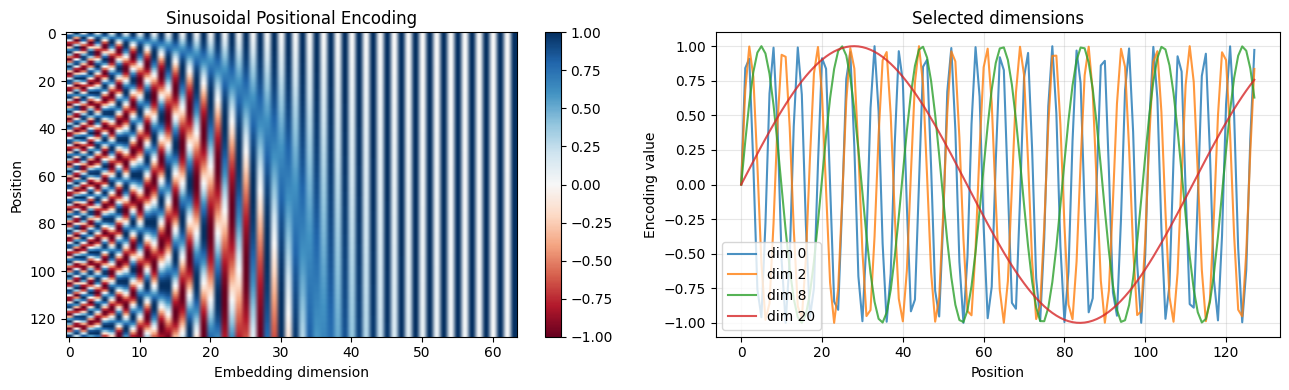

In [33]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017)."""

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the (max_len, d_model) table of encodings
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()          # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )                                                                   # (d_model/2,)
        pe[:, 0::2] = torch.sin(position * div_term)   # even dims
        pe[:, 1::2] = torch.cos(position * div_term)   # odd  dims

        # Register as a buffer (not a learnable parameter, but moves with .to(device))
        self.register_buffer('pe', pe.unsqueeze(0))    # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


# ── Visualise the encoding ─────────────────────────────────────────────────────
D_MODEL = 64

pe_module = PositionalEncoding(D_MODEL, max_len=SEQ_LEN)
pe_matrix = pe_module.pe[0].detach().numpy()   # (SEQ_LEN, D_MODEL)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].imshow(pe_matrix, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_xlabel("Embedding dimension")
axes[0].set_ylabel("Position")
axes[0].set_title("Sinusoidal Positional Encoding")
plt.colorbar(axes[0].images[0], ax=axes[0])

# A few individual dimensions to show sinusoidal structure
for i, dim in enumerate([0, 2, 8, 20]):
    axes[1].plot(pe_matrix[:, dim], label=f"dim {dim}", alpha=0.8)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Encoding value")
axes[1].set_title("Selected dimensions")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 3: Scaled Dot-Product Attention

The core operation of the Transformer. Given queries $Q$, keys $K$, and values $V$:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

For a **decoder** (language model), we also apply a **causal mask** that sets future positions to $-\infty$ before the softmax, ensuring position $t$ can only attend to positions $\leq t$.

In [34]:
def scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Scaled dot-product attention.

    Arguments
    ---------
    Q, K : (batch, heads, seq, d_k)
    V    : (batch, heads, seq, d_v)
    mask : (1, 1, seq, seq) boolean tensor — True where attention IS allowed.

    Returns
    -------
    output : (batch, heads, seq, d_v)
    weights: (batch, heads, seq, seq)    — softmax attention probabilities
    """
    d_k = Q.size(-1)

    # Compatibility scores: (batch, heads, seq_q, seq_k)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)

    # Causal mask: block future positions by setting their score to -inf
    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))

    # Attention weights (rows sum to 1)
    weights = F.softmax(scores, dim=-1)      # (batch, heads, seq, seq)

    # Weighted combination of values
    output = weights @ V                     # (batch, heads, seq, d_v)
    return output, weights


# ── Quick test ─────────────────────────────────────────────────────────────────
B, H, S, dk, dv = 2, 4, 8, 16, 16

Q_test = torch.randn(B, H, S, dk)
K_test = torch.randn(B, H, S, dk)
V_test = torch.randn(B, H, S, dv)

# Causal mask: lower-triangular, shape (1, 1, S, S)
causal = torch.tril(torch.ones(S, S)).bool().unsqueeze(0).unsqueeze(0)

out, attn = scaled_dot_product_attention(Q_test, K_test, V_test, mask=causal)
print("Output shape :", out.shape)            # (2, 4, 8, 16)
print("Weights shape:", attn.shape)           # (2, 4, 8, 8)
print("Weights sum to 1 (per row):", attn[0, 0].sum(dim=-1).round(decimals=4))
print("Upper triangle is 0 (causal):", (attn[0, 0][0, 1].item() == 0.0))

Output shape : torch.Size([2, 4, 8, 16])
Weights shape: torch.Size([2, 4, 8, 8])
Weights sum to 1 (per row): tensor([1., 1., 1., 1., 1., 1., 1., 1.])
Upper triangle is 0 (causal): True


---
## Part 4: Multi-Head Attention

Running $h$ attention heads in parallel allows the model to capture different types of relationships simultaneously. Each head projects the input to a lower-dimensional space ($d_k = d / h$), attends independently, and the results are concatenated and re-projected:

$$\text{head}_i = \text{Attention}(x W_i^Q,\; x W_i^K,\; x W_i^V)$$
$$\text{MultiHead}(x) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W^O$$

The computational cost is the same as single-head attention with dimension $d$, but the model gets $h$ different "perspectives" on the sequence.

In [35]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention layer."""

    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_k    = d_model // n_heads
        self.n_heads = n_heads

        # Single projection matrices (more efficient than h separate ones)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        x    : (batch, seq_len, d_model)
        mask : (1, 1, seq_len, seq_len) causal mask (True = allowed)
        """
        batch, seq_len, _ = x.shape

        def split_heads(t: torch.Tensor) -> torch.Tensor:
            """(batch, seq, d_model) → (batch, n_heads, seq, d_k)"""
            return t.view(batch, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        Q = split_heads(self.W_q(x))   # (batch, h, seq, d_k)
        K = split_heads(self.W_k(x))
        V = split_heads(self.W_v(x))

        # Attend
        out, attn = scaled_dot_product_attention(Q, K, V, mask)

        # Merge heads: (batch, h, seq, d_k) → (batch, seq, d_model)
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, self.n_heads * self.d_k)
        return self.W_o(out), attn   # (batch, seq, d_model), (batch, h, seq, seq)


# ── Test ───────────────────────────────────────────────────────────────────────
mha = MultiHeadAttention(d_model=64, n_heads=4)
x_test = torch.randn(2, 10, 64)
mask   = torch.tril(torch.ones(10, 10)).bool().unsqueeze(0).unsqueeze(0)
out, w = mha(x_test, mask)
print("MHA output shape:", out.shape)   # (2, 10, 64)
print("Attn weight shape:", w.shape)    # (2, 4, 10, 10)

MHA output shape: torch.Size([2, 10, 64])
Attn weight shape: torch.Size([2, 4, 10, 10])


---
## Part 5: The Feed-Forward Sub-Layer

After attention, each position is transformed independently by a small two-layer MLP:

$$\text{FFN}(x) = \text{GELU}(x W_1 + b_1)\, W_2 + b_2$$

GELU (Gaussian Error Linear Unit) is a smooth approximation to ReLU used in all modern Transformers (GPT, BERT):

$$\text{GELU}(z) = z \cdot \Phi(z)$$

where $\Phi$ is the standard normal CDF. Typically $d_{ff} = 4 d$ (hidden dimension is four times the model dimension).

In [36]:
class FeedForward(nn.Module):
    """Position-wise feed-forward sub-layer: Linear → GELU → Dropout → Linear."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

---
## Part 6: Transformer Block — Residual Connections & Layer Normalization

### Why Residual Connections?

In a plain deep network, the gradient of the loss $J$ with respect to early-layer parameters is a product of many Jacobians. If each has spectral norm $< 1$ (e.g. saturating activations), the product shrinks exponentially — **vanishing gradients**.

A residual block computes $\text{output} = x + \mathcal{F}(x)$, so:

$$\frac{\partial J}{\partial x} = \frac{\partial J}{\partial \text{output}} \cdot \underbrace{\left(I + \frac{\partial \mathcal{F}(x)}{\partial x}\right)}_{\text{always contains identity}}$$

The identity term $I$ ensures that the gradient is **at least as large** as the upstream gradient — a direct highway through the entire network.

### Why Layer Normalization (not Batch Normalization)?

| | **Batch Norm** | **Layer Norm** |
|---|---|---|
| Statistics computed over | Batch dimension ($m$ examples) | Feature dimension ($d$ features) |
| Same at train and inference? | No (uses running averages at test time) | **Yes** |
| Works with a single example? | No | **Yes** |
| Works with variable-length sequences? | No | **Yes** |
| Standard in Transformers? | No | **Yes** |

**Layer Norm** normalises each token's representation independently:

$$\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta, \quad \mu = \frac{1}{d}\sum_j x_j, \quad \sigma^2 = \frac{1}{d}\sum_j (x_j - \mu)^2$$

### Pre-Norm Architecture

We use the modern **Pre-Norm** variant (GPT-2 style), where LayerNorm is applied *before* each sub-layer. This leaves the residual stream completely clean:

$$x' = x + \text{Dropout}\!\left(\text{Attention}\!\left(\text{LayerNorm}(x)\right)\right)$$
$$x'' = x' + \text{Dropout}\!\left(\text{FFN}\!\left(\text{LayerNorm}(x')\right)\right)$$

### RMSNorm: A Lighter Alternative

**Root Mean Square Layer Normalization (RMSNorm)** (Zhang & Sennrich, 2019) simplifies LayerNorm by dropping the mean-subtraction step entirely. Instead of normalising to zero mean and unit variance, it only rescales by the **root mean square** of the activations:

$$\text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)} \cdot \gamma, \qquad \text{RMS}(x) = \sqrt{\frac{1}{d}\sum_{j=1}^{d} x_j^2}$$

The gain $\gamma \in \mathbb{R}^d$ is still learned; the bias $\beta$ is dropped entirely.

**Why remove re-centring?** The hypothesis is that the stabilising effect of LayerNorm comes primarily from re-scaling (controlling the norm of activations), not from re-centring (shifting the mean). The mean subtraction doubles the computation and adds a learned bias that may be redundant when the model already has linear layers with biases. Empirically, removing it causes no loss in quality.

| Property | LayerNorm | RMSNorm |
|----------|-----------|---------|
| Mean subtraction ($-\mu$) | Yes | **No** |
| Learned bias $\beta$ | Yes | **No** |
| Learned scale $\gamma$ | Yes | Yes |
| Parameters per layer | $2d$ | $d$ |
| Computational cost | Two statistics ($\mu$, $\sigma^2$) | **One statistic** (RMS) |
| Used in | BERT, GPT-2 | **LLaMA, Mistral, Gemma** |

RMSNorm is the default normalisation in the LLaMA family and most modern open-weight LLMs. The code cell below implements it and compares it numerically with LayerNorm.

In [37]:
class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization (Zhang & Sennrich, 2019).

    Used by LLaMA, Mistral, Gemma, and other modern open-weight LLMs.
    Normalises by the RMS of the activations — no mean subtraction, no bias.

        RMSNorm(x) = (x / RMS(x)) * γ,   RMS(x) = sqrt(mean(x²) + ε)
    """

    def __init__(self, d_model: int, eps: float = 1e-8):
        super().__init__()
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(d_model))   # learnable scale (no bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Compute RMS over the last (feature) dimension
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.gamma


# ── Numerical comparison: LayerNorm vs. RMSNorm ───────────────────────────────
torch.manual_seed(0)
d_cmp   = 64
x_cmp   = torch.randn(4, 16, d_cmp)

ln_cmp  = nn.LayerNorm(d_cmp)
rms_cmp = RMSNorm(d_cmp)

out_ln  = ln_cmp(x_cmp)
out_rms = rms_cmp(x_cmp)

print("── Statistics before and after normalisation ──────────────────────────")
print(f"Input       mean={x_cmp.mean().item():+.4f}  std={x_cmp.std().item():.4f}")
print(f"LayerNorm   mean={out_ln.mean().item():+.6f}  std={out_ln.std().item():.4f}"
      "   ← re-centres AND re-scales")
print(f"RMSNorm     mean={out_rms.mean().item():+.4f}  std={out_rms.std().item():.4f}"
      "   ← re-scales only (mean not forced to 0)")

# ── Parameter count ───────────────────────────────────────────────────────────
p_ln  = sum(p.numel() for p in ln_cmp.parameters())
p_rms = sum(p.numel() for p in rms_cmp.parameters())
print(f"\n── Parameters (d = {d_cmp}) ─────────────────────────────────────────────")
print(f"LayerNorm: {p_ln}  (γ ∈ ℝ^d  +  β ∈ ℝ^d)")
print(f"RMSNorm:   {p_rms}  (γ ∈ ℝ^d  only — no bias)")

# ── Verify the RMS of each token is ≈ 1 after normalisation ──────────────────
rms_after = out_rms.pow(2).mean(-1).sqrt()
print(f"\nRMS of RMSNorm output (γ=1 init): mean={rms_after.mean().item():.4f}"
      "  (expected ≈ 1.0)")

── Statistics before and after normalisation ──────────────────────────
Input       mean=-0.0096  std=0.9934
LayerNorm   mean=+0.000000  std=1.0001   ← re-centres AND re-scales
RMSNorm     mean=-0.0119  std=1.0001   ← re-scales only (mean not forced to 0)

── Parameters (d = 64) ─────────────────────────────────────────────
LayerNorm: 128  (γ ∈ ℝ^d  +  β ∈ ℝ^d)
RMSNorm:   64  (γ ∈ ℝ^d  only — no bias)

RMS of RMSNorm output (γ=1 init): mean=1.0000  (expected ≈ 1.0)


In [38]:
class TransformerBlock(nn.Module):
    """
    One Transformer layer (Pre-LayerNorm variant):

        x'  = x  + Dropout( Attention( LayerNorm(x) ) )   <- residual 1
        x'' = x' + Dropout(    FFN   ( LayerNorm(x') ) )  <- residual 2
    """

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads)
        self.ff    = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)    # Layer Normalization
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        # Sub-layer 1: Multi-Head Self-Attention
        attn_out, attn_weights = self.attn(self.norm1(x), mask)
        x = x + self.drop(attn_out)            # residual connection 1

        # Sub-layer 2: Position-wise Feed-Forward
        x = x + self.drop(self.ff(self.norm2(x)))  # residual connection 2

        return x, attn_weights


# Demonstrate that residual connections preserve gradient magnitude
d, seq = 64, 16
block = TransformerBlock(d_model=d, n_heads=4, d_ff=256)

x_in  = torch.randn(1, seq, d, requires_grad=True)
mask  = torch.tril(torch.ones(seq, seq)).bool().unsqueeze(0).unsqueeze(0)
x_out, _ = block(x_in, mask)

x_out.sum().backward()

print(f"Input grad norm (1 block): {x_in.grad.norm().item():.4f}")
print("In a plain deep network without residuals, this shrinks exponentially with depth.")

Input grad norm (1 block): 35.2543
In a plain deep network without residuals, this shrinks exponentially with depth.


---
## Part 7: Full Transformer Language Model

We stack $L$ Transformer blocks, add a final LayerNorm, and project to vocabulary logits:

For language modeling, position $t$ predicts character $t+1$, which is why the target $y$ is the input shifted by one position.

In [39]:
class TransformerLM(nn.Module):
    """Decoder-only Transformer for character-level language modelling (GPT-style)."""

    def __init__(
        self,
        vocab_size: int,
        d_model:    int = 64,
        n_heads:    int = 4,
        n_layers:   int = 3,
        d_ff:       int = 256,
        max_len:    int = 512,
        dropout:    float = 0.1,
    ):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(d_model)           # final LayerNorm (Pre-Norm architecture)
        self.head = nn.Linear(d_model, vocab_size)  # project to vocabulary logits

        self._init_weights()

    # ------------------------------------------------------------------
    def _init_weights(self):
        """GPT-style initialisation: N(0, 0.02) for all linear and embedding layers."""
        for module in self.modules():
            if isinstance(module, (nn.Linear, nn.Embedding)):
                nn.init.normal_(module.weight, std=0.02)
                if hasattr(module, 'bias') and module.bias is not None:
                    nn.init.zeros_(module.bias)

    # ------------------------------------------------------------------
    def forward(
        self, idx: torch.Tensor
    ) -> tuple[torch.Tensor, list[torch.Tensor]]:
        """
        idx : (batch, seq_len)  — token indices
        returns
            logits   : (batch, seq_len, vocab_size)
            all_attn : list of (batch, n_heads, seq_len, seq_len)  per layer
        """
        batch, seq_len = idx.shape

        # Causal (lower-triangular) mask: True = this pair can attend
        mask = (
            torch.tril(torch.ones(seq_len, seq_len, device=idx.device))
            .bool()
            .unsqueeze(0).unsqueeze(0)   # (1, 1, seq_len, seq_len)
        )

        # Embed tokens and add positional encoding
        h = self.pos_enc(self.token_emb(idx))   # (batch, seq_len, d_model)

        all_attn = []
        for block in self.blocks:
            h, attn = block(h, mask)
            all_attn.append(attn)

        h      = self.norm(h)
        logits = self.head(h)   # (batch, seq_len, vocab_size)
        return logits, all_attn


# ── Instantiate and inspect ────────────────────────────────────────────────────
N_HEADS  = 4
N_LAYERS = 3
D_FF     = 256

model = TransformerLM(
    vocab_size = vocab_size,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    d_ff       = D_FF,
    max_len    = SEQ_LEN * 2,
    dropout    = 0.1,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

# Quick forward pass
idx_test = torch.randint(0, vocab_size, (2, SEQ_LEN)).to(device)
logits_test, attns_test = model(idx_test)
print(f"\nInput shape : {idx_test.shape}")
print(f"Output shape: {logits_test.shape}  (batch, seq_len, vocab_size)")

TransformerLM(
  (token_emb): Embedding(65, 64)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=False)
        (W_k): Linear(in_features=64, out_features=64, bias=False)
        (W_v): Linear(in_features=64, out_features=64, bias=False)
        (W_o): Linear(in_features=64, out_features=64, bias=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
        )
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((64,

---
## Part 8: Training

The training objective is **cross-entropy** over next-character predictions. For each position $t$ in the sequence, the model outputs a probability distribution over the vocabulary and is trained to assign high probability to the true next character $y_t$.

We use:
- **Adam** optimiser with learning rate $3 \times 10^{-4}$.
- **Gradient clipping** (max norm = 1.0) to prevent gradient spikes.
- **`model.train()` / `model.eval()`** to control Dropout behaviour.
- A **validation loss** sampled every 500 steps on `data_val` to monitor generalisation.

> **Note on training time.** With ~1 M training characters and a sequence length of 128, each gradient step processes many more tokens than the original small excerpt. On CPU expect several minutes; on GPU this runs in under a minute. The validation loss should track the training loss — unlike the tiny excerpt where the model memorised the text, there is now genuine room for generalisation.

In [40]:
N_STEPS   = 5000
LR        = 3e-4
CLIP_NORM = 1.0

optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
losses     = []
val_losses = []   # list of (step, val_loss) pairs

model.train()
for step in range(N_STEPS):
    X, y = get_batch(data, SEQ_LEN, BATCH_SIZE, device)

    optimizer.zero_grad()

    logits, _ = model(X)                          # (batch, seq, vocab_size)
    loss = F.cross_entropy(
        logits.view(-1, vocab_size),              # (batch*seq, vocab_size)
        y.view(-1)                                # (batch*seq,)
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
    optimizer.step()

    losses.append(loss.item())

    if (step + 1) % 500 == 0:
        # Estimate validation loss (no gradient update)
        model.eval()
        with torch.no_grad():
            X_v, y_v  = get_batch(data_val, SEQ_LEN, BATCH_SIZE, device)
            logits_v, _ = model(X_v)
            val_loss  = F.cross_entropy(logits_v.view(-1, vocab_size), y_v.view(-1))
        val_losses.append((step + 1, val_loss.item()))
        model.train()
        print(f"Step {step + 1:5d}/{N_STEPS}  |  "
              f"train loss: {loss.item():.4f}  |  val loss: {val_loss.item():.4f}")

print("\nTraining complete.")
print(f"Initial loss (random): ~{math.log(vocab_size):.2f}  (log of vocab size)")
print(f"Final   train loss   :  {losses[-1]:.4f}")

Step   500/5000  |  train loss: 2.7217  |  val loss: 2.6488
Step  1000/5000  |  train loss: 2.3902  |  val loss: 2.3874
Step  1500/5000  |  train loss: 2.3117  |  val loss: 2.2837
Step  2000/5000  |  train loss: 2.2041  |  val loss: 2.1785
Step  2500/5000  |  train loss: 2.1608  |  val loss: 2.0915
Step  3000/5000  |  train loss: 2.1230  |  val loss: 2.0605
Step  3500/5000  |  train loss: 2.0319  |  val loss: 2.0048
Step  4000/5000  |  train loss: 1.9507  |  val loss: 1.9268
Step  4500/5000  |  train loss: 1.9737  |  val loss: 1.9040
Step  5000/5000  |  train loss: 1.9304  |  val loss: 1.8744

Training complete.
Initial loss (random): ~4.17  (log of vocab size)
Final   train loss   :  1.9304


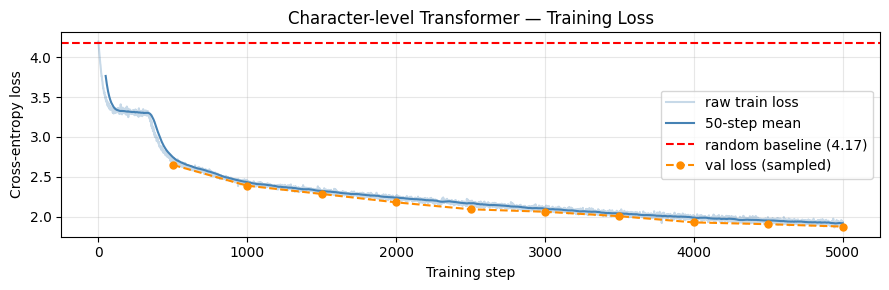

In [41]:
# Plot the training loss curve (with validation markers)
window = 50   # moving average window for smoothing
smooth = np.convolve(losses, np.ones(window) / window, mode='valid')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(losses, alpha=0.3, color='steelblue', label='raw train loss')
ax.plot(np.arange(window - 1, len(losses)), smooth,
        color='steelblue', label=f'{window}-step mean')
ax.axhline(math.log(vocab_size), color='red', linestyle='--',
           label=f'random baseline ({math.log(vocab_size):.2f})')

if val_losses:
    val_steps, val_ls = zip(*val_losses)
    ax.plot(val_steps, val_ls, 'o--', color='darkorange',
            markersize=5, label='val loss (sampled)')

ax.set_xlabel("Training step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Character-level Transformer — Training Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 9: Text Generation

After training, we use the model in **autoregressive** mode: we feed it a prompt, sample the next character from the predicted distribution, append it to the sequence, and repeat.

The `temperature` parameter controls the sharpness of the distribution:
- **High temperature** ($> 1$): more uniform → more creative / random.
- **Low temperature** ($ < 1$): more peaked → more conservative / repetitive.

In [42]:
@torch.no_grad()
def generate(
    model:       TransformerLM,
    prompt:      str,
    n_chars:     int   = 200,
    temperature: float = 0.8,
) -> str:
    """Autoregressively generate characters one at a time."""
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(n_chars):
        # Trim context to the last SEQ_LEN tokens (model's context window)
        idx_cond      = idx[:, -SEQ_LEN:]
        logits, _     = model(idx_cond)
        logits        = logits[:, -1, :] / temperature   # (1, vocab_size)
        probs         = F.softmax(logits, dim=-1)
        next_token    = torch.multinomial(probs, num_samples=1)   # (1, 1)
        idx           = torch.cat([idx, next_token], dim=1)

    return decode(idx[0].tolist())


print("=== Temperature 0.5 (conservative) ===")
print(generate(model, "All the world", n_chars=200, temperature=0.5))
print()
print("=== Temperature 1.0 (balanced) ===")
print(generate(model, "All the world", n_chars=200, temperature=1.0))
print()
print("=== Temperature 1.5 (creative) ===")
print(generate(model, "All the world", n_chars=200, temperature=1.5))

=== Temperature 0.5 (conservative) ===
All the world,
And not such the with hear be for as and you the him is be
The stand the she hear comer.

First Mord:
And the be with the their speak shall a forter
To the hearter a mothers the death breath their m

=== Temperature 1.0 (balanced) ===
All the world broths how a ampoot.

RAENTE:

Girs this entervalon truin:
Vayseing and will you depted there his land
That cordy of and way simly,
And your candard they shall his mansen but teist,
Hou no not; me so

=== Temperature 1.5 (creative) ===
All the world'd ae theight:
Ona blice!
Tooo tilk tispialy kquoses? O!
Sevind sitin Ttime thet, givur it. By hy qoosceos
Ridh'ds os age takbursiont Jatcendr, Sexituesy:
A, it
prepica: wy, my hoptay, Jiet you ca?;




---
## Part 10: Visualising Attention Weights

One of the most interpretable aspects of Transformers is the ability to inspect **attention weights**: for each head and each position, which other positions does it attend to most strongly?

Below we plot the attention heatmap for a short prompt across all heads of the first layer. Each row is a query position; each column is a key position. Brighter cells mean stronger attention. The lower-triangular structure reflects the causal mask.

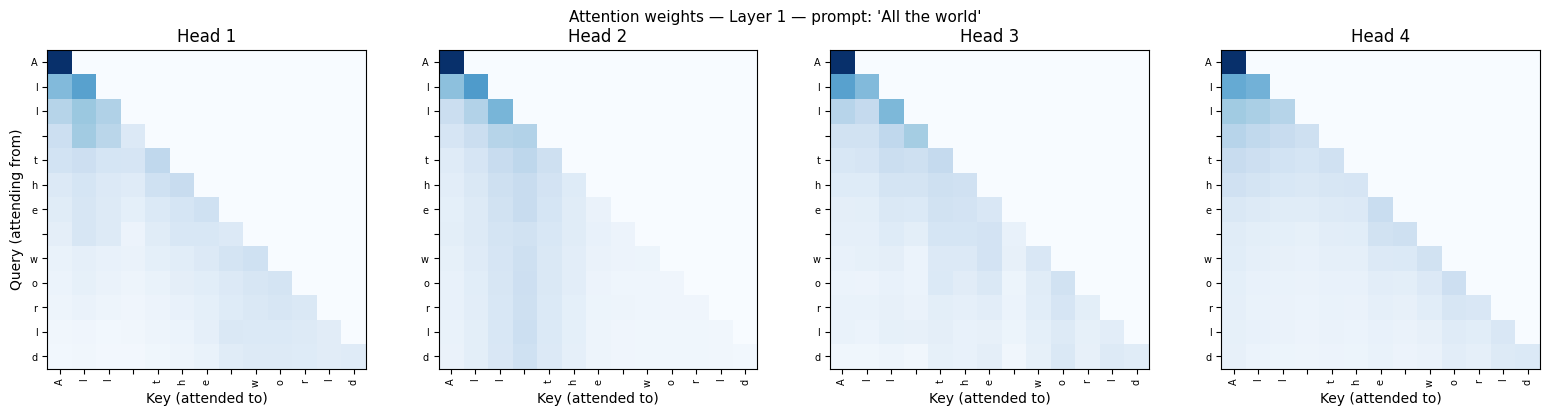

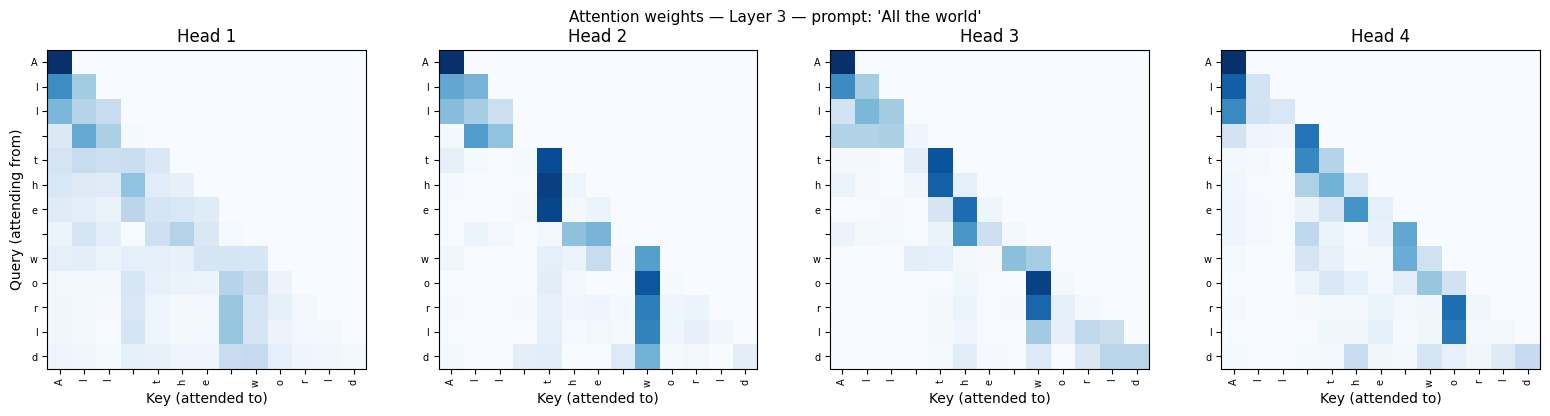

In [43]:
@torch.no_grad()
def visualise_attention(
    model:  TransformerLM,
    prompt: str,
    layer:  int = 0,
) -> None:
    """Plot all attention heads of a given layer for a text prompt."""
    model.eval()
    idx    = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    _, all_attn = model(idx)

    # all_attn[layer]: (1, n_heads, seq_len, seq_len)
    attn = all_attn[layer][0].cpu().numpy()   # (n_heads, seq, seq)
    chars = list(prompt)
    n     = len(chars)

    fig, axes = plt.subplots(1, N_HEADS, figsize=(4 * N_HEADS, 4))
    for h, ax in enumerate(axes):
        im = ax.imshow(attn[h, :n, :n], cmap='Blues', vmin=0)
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(chars, fontsize=7, rotation=90)
        ax.set_yticklabels(chars, fontsize=7)
        ax.set_title(f"Head {h + 1}")
        ax.set_xlabel("Key (attended to)")
        if h == 0:
            ax.set_ylabel("Query (attending from)")

    fig.suptitle(f"Attention weights — Layer {layer + 1} — prompt: {prompt!r}", fontsize=11)
    plt.tight_layout()
    plt.show()


# Use a short prompt so the heatmap labels are readable
PROMPT = "All the world"
visualise_attention(model, PROMPT, layer=0)
visualise_attention(model, PROMPT, layer=N_LAYERS - 1)